# **StackOverflow Analysis**

{headline}

In [689]:
#Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_rows', None)
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.width', 0)
pd.reset_option('display.max_colwidth')
pd.reset_option('display.width')


## Data Loading and Preparation


In [651]:
# Load datasets
questions = pd.read_csv("StackOverflow Data\\question_volume.csv")
users = pd.read_csv("StackOverflow Data\\user_registration.csv")
votes = pd.read_csv("StackOverflow Data\\votes_over_time.csv")
comments = pd.read_csv("StackOverflow Data\\daily_random_selection_NOFILTER.csv")

In [652]:
#Print dimensions of the data files
for name, df in [('Questions', questions), ('Users', users), ('Votes', votes), ('Comments', comments)]:
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns\n")

Questions: 86 rows, 3 columns

Users: 86 rows, 3 columns

Votes: 86 rows, 5 columns

Comments: 48096 rows, 7 columns



In [653]:
#Create date column in each table and check datatypes
dfs = {
    "questions": questions,
    "users": users,
    "votes": votes,
    "comments": comments
}

for name, df in dfs.items():
    df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
    print(f"\n{name} dtypes:\n", df.dtypes)


questions dtypes:
 year                       int64
month                      int64
question_count             int64
date              datetime64[ns]
dtype: object

users dtypes:
 year                  int64
month                 int64
new_users             int64
date         datetime64[ns]
dtype: object

votes dtypes:
 year                    int64
month                   int64
upvotes                 int64
downvotes               int64
total_votes             int64
date           datetime64[ns]
dtype: object

comments dtypes:
 Id                       int64
Text                    object
Score                    int64
CreationDate            object
year                     int64
month                    int64
rn                       int64
date            datetime64[ns]
dtype: object


In [654]:
#convert comments text to string
comments['Text'] = comments['Text'].astype(str)

## Initial Visualizations

**Question Volume Over Time**

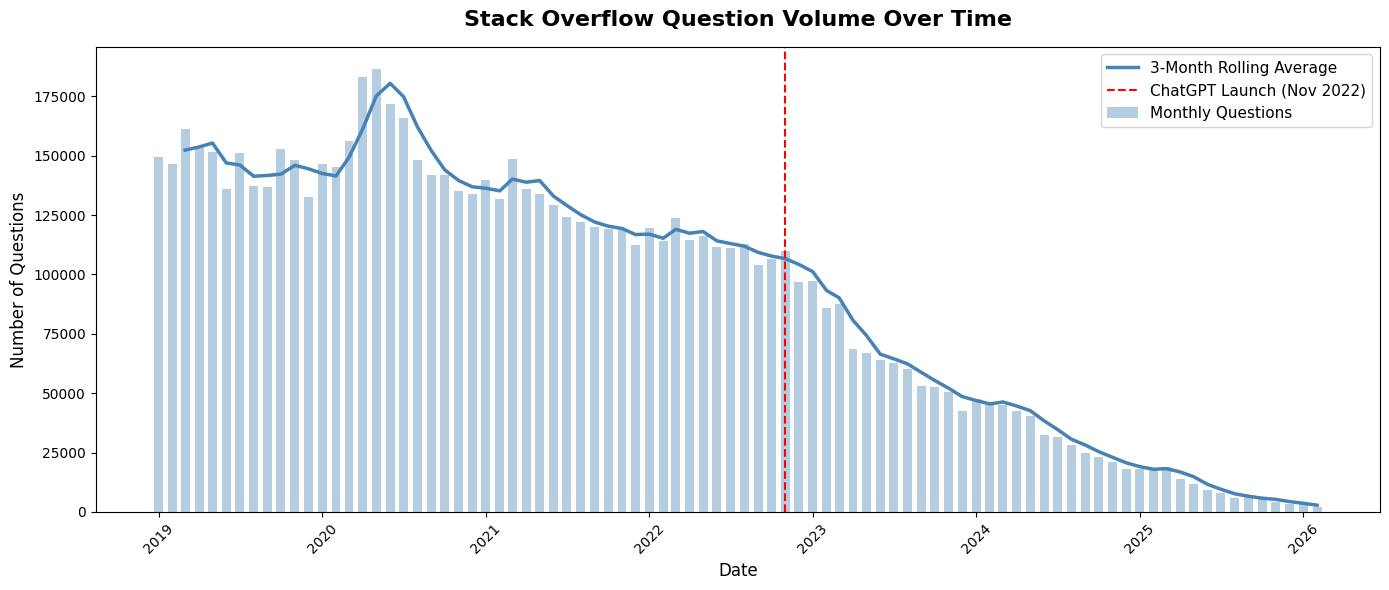

In [655]:
# Calculate rolling average
questions['rolling_avg'] = questions['question_count'].rolling(window=3).mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

# Monthly bars
ax.bar(questions['date'], questions['question_count'], color='steelblue', alpha=0.4, width=20, label='Monthly Questions')

# Rolling average line
ax.plot(questions['date'], questions['rolling_avg'], color='steelblue', linewidth=2.5, label='3-Month Rolling Average')

# ChatGPT launch line
ax.axvline(pd.Timestamp('2022-11-01'), color='red', linestyle='--', linewidth=1.5, label='ChatGPT Launch (Nov 2022)')

# Labels and formatting
ax.set_title('Stack Overflow Question Volume Over Time', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Questions', fontsize=12)
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('chart1_question_volume.png', dpi=150)
plt.show()

**New Users Over Time**

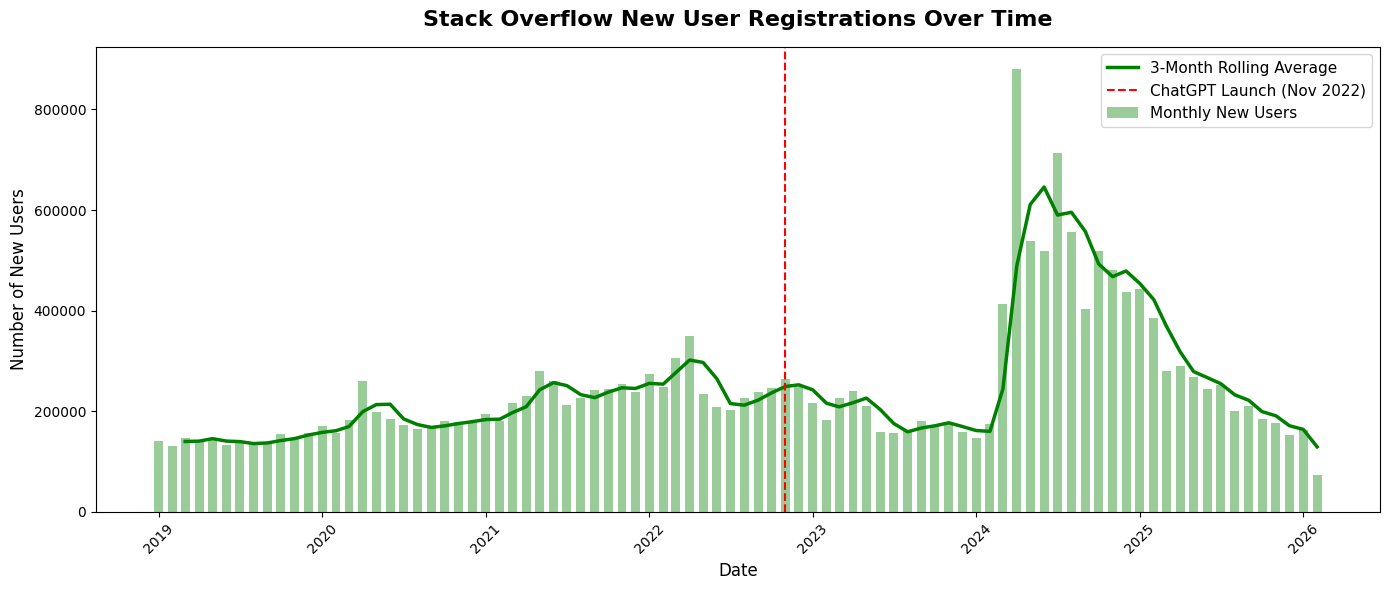

In [656]:
# Calculate rolling average
users['rolling_avg'] = users['new_users'].rolling(window=3).mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

# Monthly bars
ax.bar(users['date'], users['new_users'], color='green', alpha=0.4, width=20, label='Monthly New Users')

# Rolling average line
ax.plot(users['date'], users['rolling_avg'], color='green', linewidth=2.5, label='3-Month Rolling Average')

# ChatGPT launch line
ax.axvline(pd.Timestamp('2022-11-01'), color='red', linestyle='--', linewidth=1.5, label='ChatGPT Launch (Nov 2022)')

# Labels and formatting
ax.set_title('Stack Overflow New User Registrations Over Time', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of New Users', fontsize=12)
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('chart2_user_registrations.png', dpi=150)
plt.show()

**Votes Over Time**

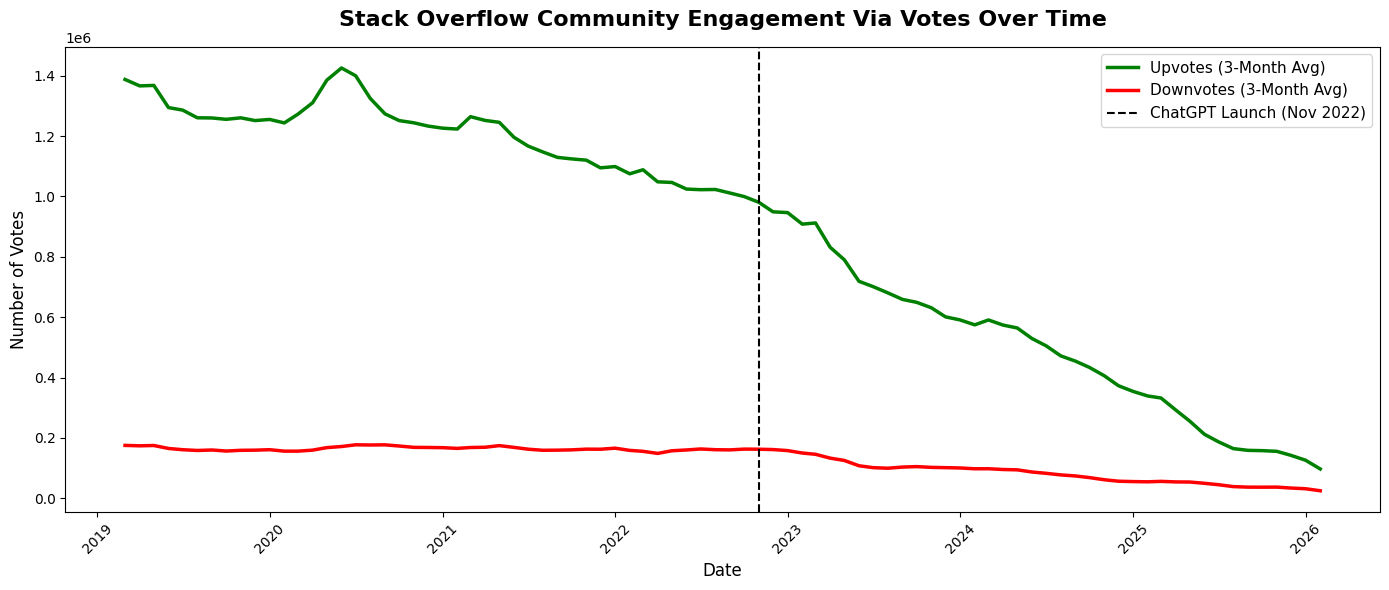

In [657]:
# Calculate rolling averages
votes['upvotes_rolling'] = votes['upvotes'].rolling(window=3).mean()
votes['downvotes_rolling'] = votes['downvotes'].rolling(window=3).mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(votes['date'], votes['upvotes_rolling'], color='green', linewidth=2.5, label='Upvotes (3-Month Avg)')
ax.plot(votes['date'], votes['downvotes_rolling'], color='red', linewidth=2.5, label='Downvotes (3-Month Avg)')

ax.axvline(pd.Timestamp('2022-11-01'), color='black', linestyle='--', linewidth=1.5, label='ChatGPT Launch (Nov 2022)')

ax.set_title('Stack Overflow Community Engagement Via Votes Over Time', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Votes', fontsize=12)
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('chart4_votes.png', dpi=150)
plt.show()

## Sentiment Analysis Using VADER

In [658]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer= SentimentIntensityAnalyzer()

In [690]:
#fill any missing values with an empty string
comments['Text'] = comments['Text'].fillna('')

#find sentiment scores for each comment and store it in a new column
comments['sentiment_score']=comments['Text'].apply(
    lambda a: analyzer.polarity_scores(a)['compound']
)

# convert VADER compound score into a text label
def label_sentiment(sentiment_score):
    if sentiment_score>0.05:
        return 'positive'
    elif sentiment_score<-0.05:
        return 'negative'
    else:
        return 'neutral'

# create a new column with all text labels
comments['sentiment_label'] = comments['sentiment_score'].apply(label_sentiment)

print(comments[['Text','sentiment_score','sentiment_label']].head(10))

                                                Text  sentiment_score  \
0  see this post [Appended childs through appendC...           0.0000   
1  You have basically answered you own question,....          -0.2725   
2  In other words: this answer looks nice to thos...          -0.1263   
3  you need to split the string with '+' and calc...           0.0000   
4  This looks like JSON, can't you use a JSON par...           0.3612   
5  Why not just concatenate the lists with `+`? O...           0.0000   
6  @ManosKounelakis but you only need to learn wh...          -0.2960   
7  What does "not working" mean to you here? What...          -0.4137   
8  @willbattel I just replied to your Google post...           0.7088   
9  If I decompose it in two keys it works:\n1) no...           0.0000   

  sentiment_label  
0         neutral  
1        negative  
2        negative  
3         neutral  
4        positive  
5         neutral  
6        negative  
7        negative  
8        positiv

In [660]:
#visualize distribution of comment text labels
label_counts = comments['sentiment_label'].value_counts().reset_index()
label_counts.columns = ['sentiment_label', 'count']
label_counts['percent'] = label_counts['count'] / label_counts['count'].sum()

#shows the distribution of sentiments over the whole comments dataset : not that useful for the analysis - keep for now 
fig = px.bar(
    label_counts,
    x='sentiment_label',
    y='percent',
    text=label_counts['percent'].apply(lambda x: f"{x:.1%}"),
    title='Distribution of Comment Sentiment Labels',    
)

fig.update_traces(textposition='outside')

fig.update_layout(
    xaxis_title='Sentiment Label',
    yaxis_title='Percentage',
    yaxis_tickformat='.0%'  # formats axis as %
)

fig.show()

PRE VS POST CHATGPT VADER/SENTIMENT VISUALIZATION

In [ ]:
#Assign category either pre-ChatGPT or post-ChatGPT to rows based on date
for i in [comments,questions,users,votes]:   
    i['category'] = 'post-ChatGPT' 
    i.loc[i['date'] < '2022-11-01', 'category'] = 'pre-ChatGPT'

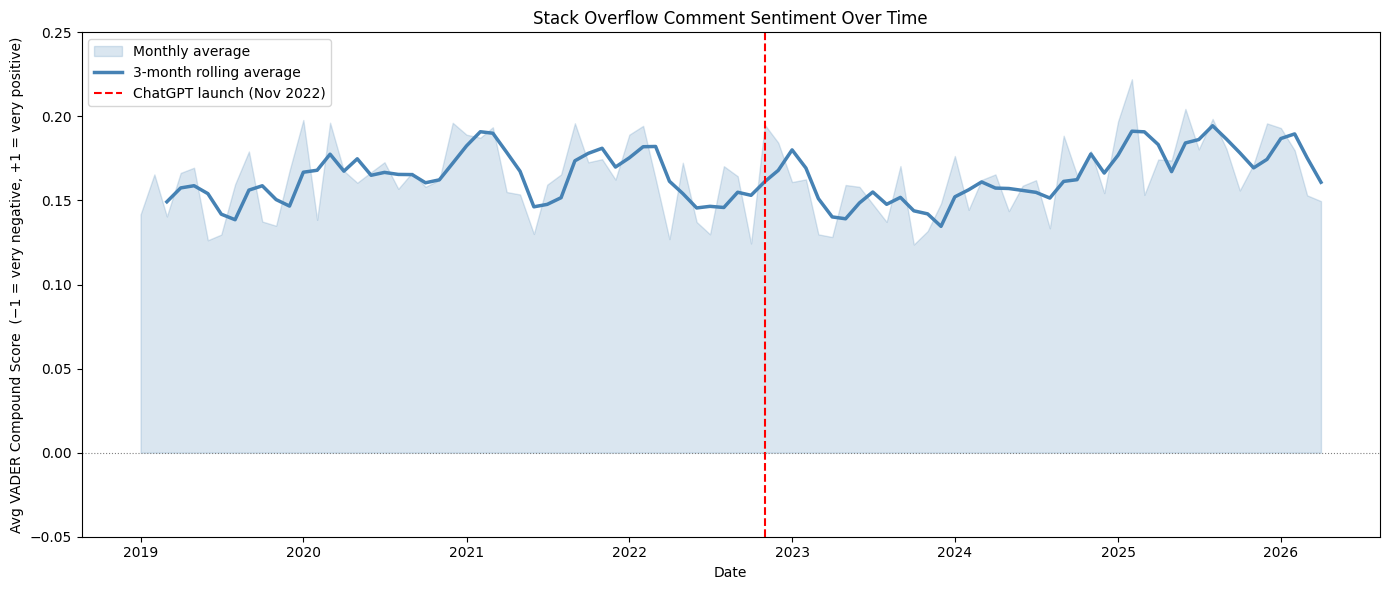

In [ ]:
# # Group by month, then calculate the average sentiment score for that month
monthly_sentiment = (
    comments
    .groupby('date')['sentiment_score']
    .agg(
        avg_sentiment='mean',    # average score that month
        std_sentiment='std',     # how spread out the scores are
        comment_count='count'    # how many comments that month 
    )
    .reset_index()               # turns the grouped index back into a regular column
    .sort_values('date')         # make sure it's in time order
)

# Add a 3-month rolling average to smooth out monthly noise
monthly_sentiment['rolling_avg'] = (
    monthly_sentiment['avg_sentiment'].rolling(window=3).mean()
)

# print(monthly_sentiment.to_string(index=False))

# set up timestamp for ChatGPT launch to use as reference line
CHATGPT_LAUNCH = pd.Timestamp('2022-11-01')

fig, ax = plt.subplots(figsize=(14, 6))

# Shaded area shows the raw monthly average
ax.fill_between(
    monthly_sentiment['date'],
    monthly_sentiment['avg_sentiment'],
    alpha=0.2, color='steelblue',
    label='Monthly average'
)

# Solid line shows the smoother rolling average
ax.plot(
    monthly_sentiment['date'],
    monthly_sentiment['rolling_avg'],
    color='steelblue', linewidth=2.5,
    label='3-month rolling average'
)

# The key reference line, everything left of this is pre-ChatGPT
ax.axvline(CHATGPT_LAUNCH, color='red', linestyle='--',
           linewidth=1.5, label='ChatGPT launch (Nov 2022)')

# A horizontal zero line to help differentiate positive vs negative
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

ax.set_ylim(-0.05, 0.25)

ax.set_title('Stack Overflow Comment Sentiment Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Avg VADER Compound Score  (−1 = very negative, +1 = very positive)')
ax.legend()
plt.tight_layout()
plt.show()

In [668]:
# calculate summary statistics for each group
sentiment_comparison = (
    comments
    .groupby('category')['sentiment_score']
    .agg(
        mean_score   = 'mean',
        median_score = 'median',
        std_score    = 'std',       
        count        = 'count'
    )
)

# reorder rows
sentiment_comparison = sentiment_comparison.loc[['pre-ChatGPT', 'post-ChatGPT']]

print("Sentiment comparison:")
print(sentiment_comparison.round(4))

# check if the ratio of the postive/negative sentiments changes 
label_mix = (
    comments
    .groupby(['category', 'sentiment_label'])
    .size()
    .unstack(fill_value=0)   #convert the grouped data from long to wide format                      
    .apply(lambda row: row / row.sum() * 100, axis=1)   #convert raw counts to percentages
    .round(1)
)

# reorder rows
label_mix = label_mix.loc[['pre-ChatGPT', 'post-ChatGPT']]

print("\nSentiment label mix (% of comments):")
print(label_mix)

Sentiment comparison:
              mean_score  median_score  std_score  count
category                                                
pre-ChatGPT       0.1623        0.0000     0.3943  25200
post-ChatGPT      0.1655        0.0542     0.4157  22896

Sentiment label mix (% of comments):
sentiment_label  negative  neutral  positive
category                                    
pre-ChatGPT          19.7     31.4      48.8
post-ChatGPT         21.6     28.1      50.3


In [692]:
#create clustered bar charts to viz pre vs post chatGPT sentiment labels
label_mix_long = (
    label_mix
    .reset_index()
    .melt(id_vars='category',
          var_name='sentiment_label',
          value_name='percentage')
)

fig = px.bar(
    label_mix_long,
    x="sentiment_label",
    y="percentage",
    color="sentiment_label",
    facet_col="category",
    barmode="group",
    color_discrete_map={
        "positive": "#90ee90",   
        "neutral": "grey",
        "negative": "#ff9999"   
    }
)

fig.update_layout(
    yaxis_title="Percentage (%)",
    title="Sentiment Label Mix: Pre vs Post ChatGPT",
    showlegend=False
)

fig.show()


# PROPHET FORECASTING
### ML Predictive Modelling

***Part 1: Predict Question Count***

In [671]:
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# rename columns to match prophet format
prophet_questions = (
    questions[['date', 'question_count']]
    .rename(columns={'date': 'ds', 'question_count': 'y'})
    .sort_values('ds')
    .reset_index(drop=True)
)

print("Prophet input format:")
print(prophet_questions.head())

Prophet input format:
          ds       y
0 2019-01-01  149608
1 2019-02-01  146408
2 2019-03-01  161134
3 2019-04-01  153545
4 2019-05-01  151374


### Train/Test Split

Train the model only on pre-ChatGPT data to generate an estimate of what the post-launch values would have been if ChatGPT had never been launched.

In [672]:
train = prophet_questions[prophet_questions['ds'] < CHATGPT_LAUNCH].copy()
test  = prophet_questions[prophet_questions['ds'] >= CHATGPT_LAUNCH].copy()

print(f"Number of Training rows (pre-ChatGPT data):  {len(train)}")
print(f"Number of Test rows     (post-ChatGPT data): {len(test)}")

Number of Training rows (pre-ChatGPT data):  46
Number of Test rows     (post-ChatGPT data): 40


In [673]:
#train the model to learn the yearly patterns from the data

model_questions = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = False,
    daily_seasonality   = False,
    interval_width      = 0.95   # 95% confidence interval around the forecast
)

model_questions.fit(train)

#model trained successfully, now predict the values for post-ChatGPT period

n_future_months = len(test) #count number of months after ChatGPT launch

future = model_questions.make_future_dataframe(
    periods=n_future_months,
    freq='MS'   #Month Start
)

#Run model on future dates to predict values
forecast_questions = model_questions.predict(future)

# -----------
#  ds ==> the date
#  yhat ==> predicted value of y
#  yhat_lower ==> lower bound of the 95% confidence interval
#  yhat_upper ==> upper bound of the 95% confidence interval
# -----------

# print("Key forecast columns:")
# print(forecast_questions[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)) #print forecasted values of last 12 months

#merge forecast values with the actual data
results_questions = prophet_questions.merge(
    forecast_questions[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on  = 'ds',
    how = 'left'
)

#calculate the effect as actual - predict
# -----------
#  if actual < predict : -ve effect ==> DROP in question count
#  if actual > predict : +ve effect ==> RISE in question count
# -----------

results_questions['effect'] = results_questions['y'] - results_questions['yhat']
print(results_questions[['ds', 'y', 'yhat', 'effect']].tail(12).to_string(index=False))

10:57:22 - cmdstanpy - INFO - Chain [1] start processing
10:57:22 - cmdstanpy - INFO - Chain [1] done processing


        ds     y         yhat        effect
2025-03-01 18897 55779.048173 -36882.048173
2025-04-01 13994 58125.767995 -44131.767995
2025-05-01 11594 57422.126325 -45828.126325
2025-06-01  9228 46476.129008 -37248.129008
2025-07-01  7783 44276.803736 -36493.803736
2025-08-01  5863 36343.311487 -30480.311487
2025-09-01  6093 31843.471162 -25750.471162
2025-10-01  5378 34282.724683 -28904.724683
2025-11-01  4311 29464.176474 -25153.176474
2025-12-01  3374 22645.465400 -19271.465400
2026-01-01  3186 31298.083260 -28112.083260
2026-02-01  1894 24009.084952 -22115.084952


Actual vs Forecast

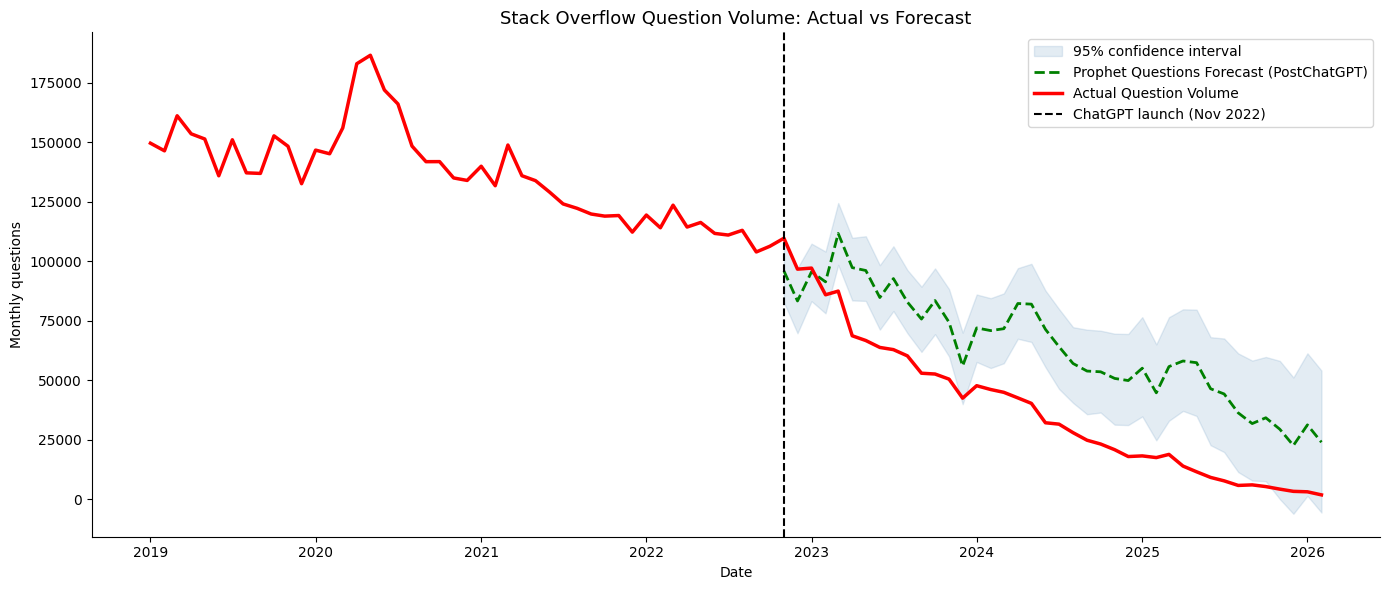

In [695]:
#Filtered dataframe for post-ChatGPT predictions
results_post = results_questions[results_questions['ds'] >= CHATGPT_LAUNCH]

#Plot the predicted values on top of actual 
fig, ax = plt.subplots(figsize=(14, 6))

#Confidence interval band
ax.fill_between(
    results_post['ds'],
    results_post['yhat_lower'],
    results_post['yhat_upper'],
    alpha = 0.15,
    color = 'steelblue',
    label = '95% confidence interval'
)

#Plot Forecast Line for only Post-ChatGPT values
ax.plot(
    results_post['ds'],
    results_post['yhat'],
    color = 'green',
    linewidth = 2,
    linestyle = '--',
    label = 'Prophet Questions Forecast (PostChatGPT)'
)

#Plot Actual Line
ax.plot(
    results_questions['ds'],
    results_questions['y'],
    color = 'red',
    linewidth = 2.5,
    label = 'Actual Question Volume'
)

#Plot ChatGPT Launch Marker
ax.axvline(
    CHATGPT_LAUNCH,
    color = 'black',
    linestyle = '--',
    linewidth = 1.5,
    label = 'ChatGPT launch (Nov 2022)'
)


ax.set_title('Stack Overflow Question Volume: Actual vs Forecast', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Monthly questions')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('forecast_questions.png', dpi=150, bbox_inches='tight')
plt.show()

***Part 2: Predict Comment Sentiments***

predict avg monthly sentiment scores after Nov 2022 as if there was no chatGPT

In [678]:
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

#rename columns to match prophet format
prophet_sentiment = (
    monthly_sentiment[['date','avg_sentiment']]
    .rename(columns={'date':'ds','avg_sentiment':'y'})
    .sort_values('ds')
    .reset_index(drop=True)
)

print("Prophet input format:")
print(prophet_sentiment.head())

Prophet input format:
          ds         y
0 2019-01-01  0.141632
1 2019-02-01  0.165502
2 2019-03-01  0.140487
3 2019-04-01  0.166378
4 2019-05-01  0.169463


In [680]:
#Split data into train and test

train_s = prophet_sentiment[prophet_sentiment['ds'] < CHATGPT_LAUNCH].copy()
test_s = prophet_sentiment[prophet_sentiment['ds'] >= CHATGPT_LAUNCH].copy()

print(f"Number of Training rows (pre-ChatGPT data):  {len(train_s)}")
print(f"Number of Test rows     (post-ChatGPT data): {len(test_s)}")

Number of Training rows (pre-ChatGPT data):  46
Number of Test rows     (post-ChatGPT data): 42


In [697]:
#train the model
model_sentiment = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = False,
    daily_seasonality   = False,
    interval_width      = 0.95   # 95% confidence interval around the forecast
)

model_sentiment.fit(train_s)
print("Model Trained Successfully!")

#model trained, now predict
future_s = model_sentiment.make_future_dataframe(
    periods=len(test_s),
    freq='MS'
)

#Run model on future dates to predict values
forecast_sentiment = model_sentiment.predict(future_s)

# -----------
#  ds ==> the date
#  yhat ==> predicted value of y
#  yhat_lower ==> lower bound of the 95% confidence interval
#  yhat_upper ==> upper bound of the 95% confidence interval
# -----------

#merge forecast values with the actual data
results_sentiment = prophet_sentiment.merge(
    forecast_sentiment[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on  = 'ds',
    how = 'left'
)

#calculate the effect as actual - predict
# -----------
#  if actual < predict : -ve effect ==> DROP in question count
#  if actual > predict : +ve effect ==> RISE in question count
# -----------
results_sentiment['effect'] = results_sentiment['y'] - results_sentiment['yhat']

print("\nPost-launch forecast vs actual (last 6 months shown):")
print(
    results_sentiment[['ds', 'y', 'yhat', 'effect']]
    .tail(6) #display the last 6 months
    .rename(columns={'y': 'actual', 'yhat': 'forecast'})
    .to_string(index=False)
)

13:32:16 - cmdstanpy - INFO - Chain [1] start processing
13:32:16 - cmdstanpy - INFO - Chain [1] done processing


Model Trained Successfully!

Post-launch forecast vs actual (last 6 months shown):
        ds   actual  forecast    effect
2025-11-01 0.171572  0.144950  0.026622
2025-12-01 0.195832  0.161129  0.034703
2026-01-01 0.193094  0.163630  0.029464
2026-02-01 0.179825  0.162322  0.017503
2026-03-01 0.153042  0.156527 -0.003485
2026-04-01 0.149598  0.143979  0.005619


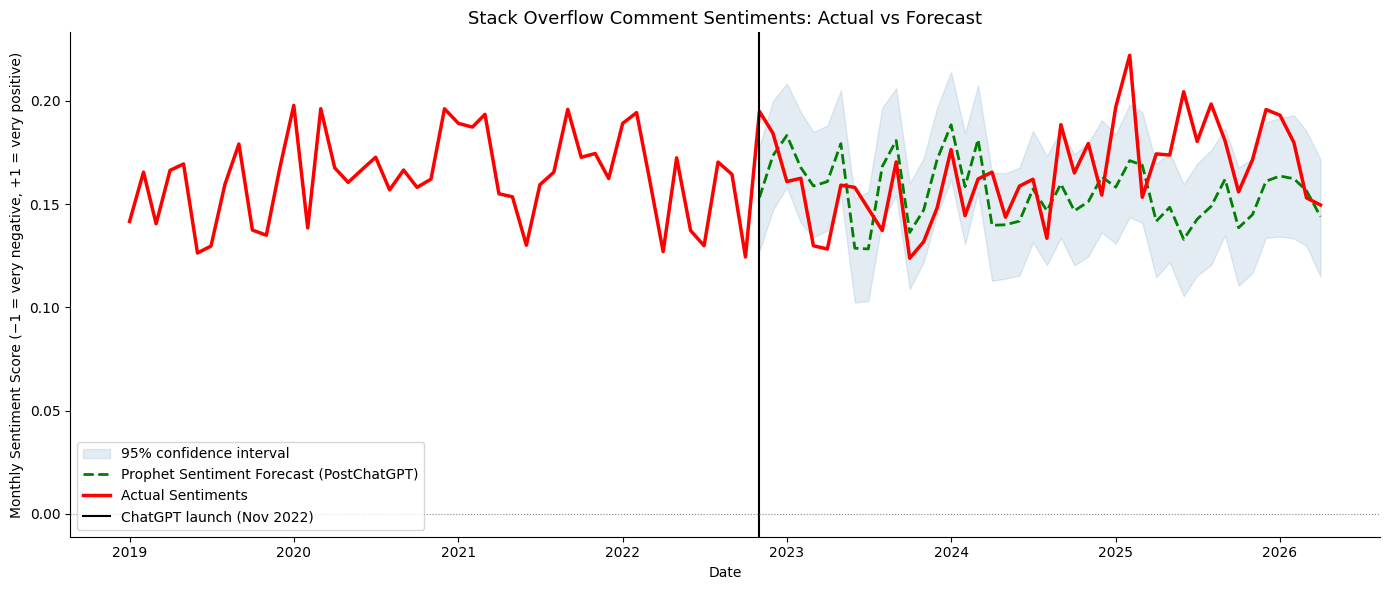

In [ ]:
#Filtered dataframe for post-ChatGPT predictions
results_sentiment_post = results_sentiment[results_sentiment['ds'] >= CHATGPT_LAUNCH]

#Plot the predicted values on top of actual 
fig, ax = plt.subplots(figsize=(14, 6))

#Confidence interval band
ax.fill_between(
    results_sentiment_post['ds'],
    results_sentiment_post['yhat_lower'],
    results_sentiment_post['yhat_upper'],
    alpha = 0.15,
    color = 'steelblue',
    label = '95% confidence interval'
)

#Plot Forecast Line for only Post-ChatGPT values
ax.plot(
    results_sentiment_post['ds'],
    results_sentiment_post['yhat'],
    color = 'green',
    linewidth = 2,
    linestyle = '--',
    label = 'Prophet Sentiment Forecast (PostChatGPT)'
)

#Plot Actual Line
ax.plot(
    results_sentiment['ds'],
    results_sentiment['y'],
    color = 'red',
    linewidth = 2.5,
    label = 'Actual Sentiments'
)

#Plot ChatGPT Launch Marker
ax.axvline(
    CHATGPT_LAUNCH,
    color = 'black',
    # linestyle = ':',
    linewidth = 1.5,
    label = 'ChatGPT launch (Nov 2022)'
)

# Zero line 
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

ax.set_title('Stack Overflow Comment Sentiments: Actual vs Forecast', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Sentiment Score (−1 = very negative, +1 = very positive)')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('forecast_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

In [701]:
'''put this in final conclusion part: to show the distiction b/w pre and post chatgpt activity'''

# ── Question volume ───────────────────────────────────────────────────────────
ques_comparison = (
    questions
    .groupby('category')['question_count']
    .mean()
)

# ── New user registrations ────────────────────────────────────────────────────
user_comparison = (
    users
    .groupby('category')['new_users']
    .mean()
)

# ── Voting behaviour ──────────────────────────────────────────────────────────
# We derive a new metric: what fraction of all votes are downvotes?
# A rising downvote ratio might mean the community is becoming more critical.
votes['downvote_ratio'] = votes['downvotes'] / votes['total_votes']

downvote_comparison = (
    votes
    .groupby('category')['downvote_ratio']
    .mean()
)

votes['upvote_ratio'] = votes['upvotes'] / votes['total_votes']

upvote_comparison = (
    votes
    .groupby('category')['upvote_ratio']
    .mean()
)

#reorder rows
ques_comparison = ques_comparison.loc[['pre-ChatGPT', 'post-ChatGPT']]
user_comparison = user_comparison.loc[['pre-ChatGPT', 'post-ChatGPT']]
downvote_comparison = downvote_comparison.loc[['pre-ChatGPT', 'post-ChatGPT']]
upvote_comparison = upvote_comparison.loc[['pre-ChatGPT', 'post-ChatGPT']]
    
# print(ques_comparison,"\n",user_comparison,"\n",downvote_comparison,"\n",upvote_comparison,"\n")

# ── Print summary ─────────────────────────────────────────────────────
print("=" * 50)
print("ACTIVITY COMPARISON: PRE vs POST ChatGPT")
print("=" * 50)

def pct_change(series):
    pre, post = series.iloc[0], series.iloc[1]
    return (post - pre) / pre * 100

print(f"\nAvg monthly questions:   {ques_comparison.iloc[0]:>10,.0f}  →  {ques_comparison.iloc[1]:>10,.0f}   ({pct_change(ques_comparison):+.1f}%)")
print(f"Avg monthly new users:   {user_comparison.iloc[0]:>10,.0f}  →  {user_comparison.iloc[1]:>10,.0f}   ({pct_change(user_comparison):+.1f}%)")
print(f"Avg downvote ratio:      {downvote_comparison.iloc[0]:>10.4f}  →  {downvote_comparison.iloc[1]:>10.4f}   ({pct_change(downvote_comparison):+.1f}%)")
print(f"Avg upvote ratio:      {upvote_comparison.iloc[0]:>10.4f}  →  {upvote_comparison.iloc[1]:>10.4f}   ({pct_change(upvote_comparison):+.1f}%)")

ACTIVITY COMPARISON: PRE vs POST ChatGPT

Avg monthly questions:      136,593  →      38,153   (-72.1%)
Avg monthly new users:      200,441  →     296,607   (+48.0%)
Avg downvote ratio:          0.1072  →      0.1392   (+29.8%)
Avg upvote ratio:          0.7819  →      0.7654   (-2.1%)


## Conclusion/ Insights/ Analysis